# Profitability Driver Analysis

# Analytical Approach

The analysis focuses on identifying key drivers of profitability
through exploratory data analysis, correlation analysis,
visualization techniques, and regression modeling.

Scatter plots, heatmaps, countplots, and statistical summaries
were selected based on the type of variables being analyzed
and their relevance to business performance.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\Krish\OneDrive\Krishna - SpringBoard\Capstone 2_Business_Analytics\Business_Analytics_Dataset_10000_Rows\Business_Analytics_Dataset_10000_Rows - Data Analysis.csv")

In [6]:
# Display first 5 rows

df.head()

,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method
0,1,CUST3818,2024-08-18,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card
1,2,CUST9689,2024-06-19,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card
2,3,CUST9147,2024-11-21,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card
3,4,CUST7938,2024-07-19,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI
4,5,CUST5127,2024-10-28,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card


# Data Cleansing

The dataset was inspected for:
- Missing values
- Duplicate records
- Incorrect data types
- Formatting inconsistencies

Findings:
- No missing values were identified
- No duplicate rows were found
- Order_Date column was converted to datetime format for analysis

In [8]:
# Check missing values
df.isnull().sum()

Order_ID            0
Customer_ID         0
Order_Date          0
Region              0
Product_Category    0
Customer_Segment    0
Quantity            0
Unit_Price          0
Discount_Rate       0
Revenue             0
Cost                0
Profit              0
Payment_Method      0
dtype: int64

In [9]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
# Check data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          10000 non-null  int64         
 1   Customer_ID       10000 non-null  object        
 2   Order_Date        10000 non-null  datetime64[ns]
 3   Region            10000 non-null  object        
 4   Product_Category  10000 non-null  object        
 5   Customer_Segment  10000 non-null  object        
 6   Quantity          10000 non-null  int64         
 7   Unit_Price        10000 non-null  float64       
 8   Discount_Rate     10000 non-null  float64       
 9   Revenue           10000 non-null  float64       
 10  Cost              10000 non-null  float64       
 11  Profit            10000 non-null  float64       
 12  Payment_Method    10000 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(2), object(5)
memory usage: 1015.8+ K

In [12]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Issue 1: Sales Drivers Analysis

Analyze how quantity sold and order volume influence
revenue and profit.

In [13]:
# Summary statistics for sales-related variables

df[['Quantity', 'Revenue', 'Profit']].describe()

,Quantity,Revenue,Profit
count,10000.00000,10000.000000,10000.000000
mean,5.51430,1195.241948,418.949768
std,2.86451,979.590244,368.418447
min,1.00000,8.590000,1.970000
25%,3.00000,396.300000,131.785000
50%,5.00000,924.365000,311.395000
75%,8.00000,1775.840000,606.845000
max,10.00000,4972.100000,2292.420000


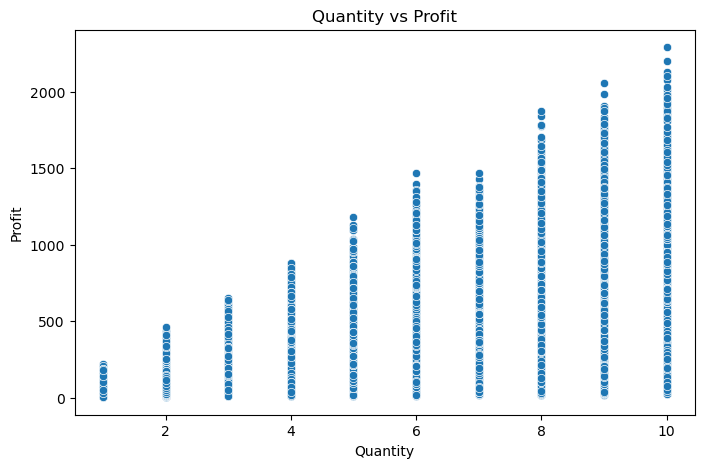

In [14]:
# Scatter plot: Quantity vs Profit

plt.figure(figsize=(8,5))

sns.scatterplot(x='Quantity',
                y='Profit',
                data=df)

plt.title('Quantity vs Profit')
plt.xlabel('Quantity')
plt.ylabel('Profit')

plt.show()

In [15]:
# Correlation analysis

df[['Quantity',
    'Revenue',
    'Profit']].corr()

,Quantity,Revenue,Profit
Quantity,1.000000,0.629814,0.587836
Revenue,0.629814,1.000000,0.929501
Profit,0.587836,0.929501,1.000000


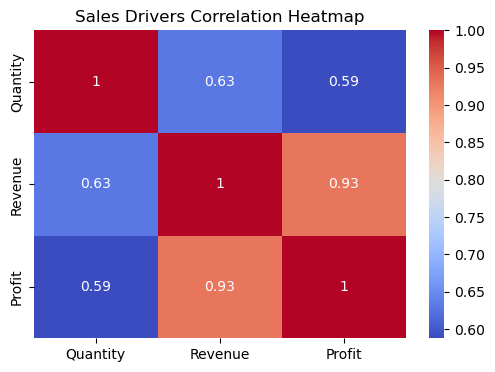

In [16]:
# Correlation heatmap

plt.figure(figsize=(6,4))

correlation = df[['Quantity',
                  'Revenue',
                  'Profit']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title('Sales Drivers Correlation Heatmap')

plt.show()

In [ ]:
## Sales Drivers Insights

The analysis identified a positive relationship between quantity sold,
revenue, and profit.

Higher sales quantities generally produce higher revenue and improved
profitability. Correlation analysis confirmed that quantity is an
important driver of revenue performance.

However, some high-volume transactions generated lower profit margins,
indicating that increased sales volume alone does not always guarantee
higher profitability.

The findings suggest that the business should focus on increasing
high-margin sales volume while maintaining effective pricing
and cost management strategies.

In [ ]:
# Issue 2: Pricing and Discount Analysis

Analyze how unit price and discount rate
impact profitability.

In [17]:
# Summary statistics for pricing variables

df[['Unit_Price',
    'Discount_Rate',
    'Revenue',
    'Profit']].describe()

,Unit_Price,Discount_Rate,Revenue,Profit
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,255.505222,0.150272,1195.241948,418.949768
std,140.832874,0.086818,979.590244,368.418447
min,10.000000,0.000000,8.590000,1.970000
25%,132.777500,0.080000,396.300000,131.785000
50%,254.995000,0.150000,924.365000,311.395000
75%,377.892500,0.230000,1775.840000,606.845000
max,499.940000,0.300000,4972.100000,2292.420000


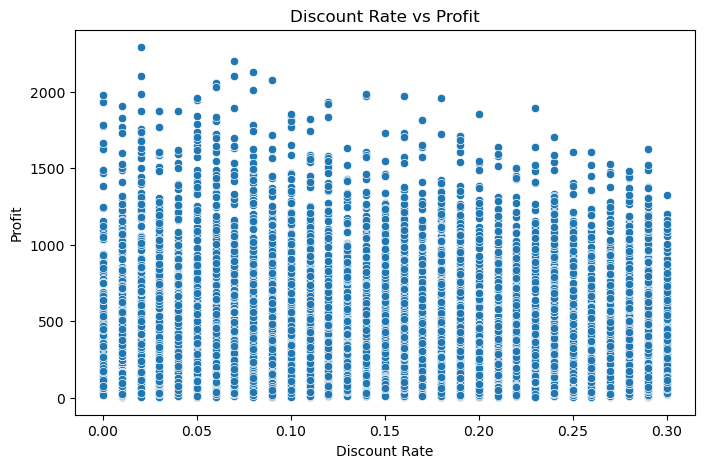

In [18]:
# Scatter plot: Discount Rate vs Profit

plt.figure(figsize=(8,5))

sns.scatterplot(x='Discount_Rate',
                y='Profit',
                data=df)

plt.title('Discount Rate vs Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')

plt.show()

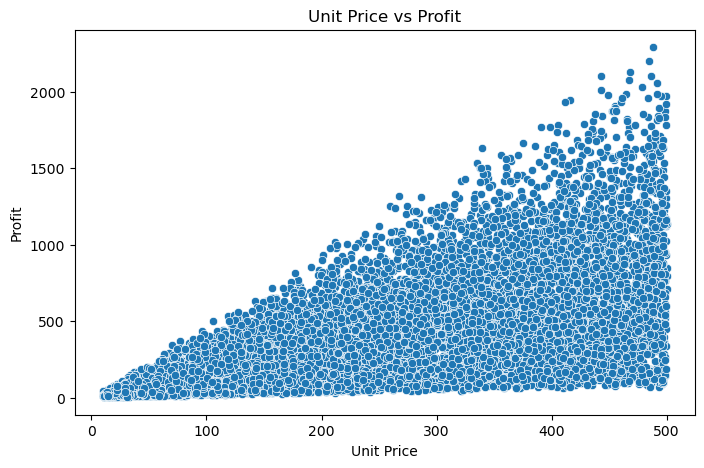

In [19]:
# Scatter plot: Unit Price vs Profit

plt.figure(figsize=(8,5))

sns.scatterplot(x='Unit_Price',
                y='Profit',
                data=df)

plt.title('Unit Price vs Profit')
plt.xlabel('Unit Price')
plt.ylabel('Profit')

plt.show()

In [20]:
# Correlation analysis for pricing variables

df[['Unit_Price',
    'Discount_Rate',
    'Revenue',
    'Profit']].corr()

,Unit_Price,Discount_Rate,Revenue,Profit
Unit_Price,1.000000,0.011367,0.671119,0.623346
Discount_Rate,0.011367,1.000000,-0.114608,-0.103951
Revenue,0.671119,-0.114608,1.000000,0.929501
Profit,0.623346,-0.103951,0.929501,1.000000


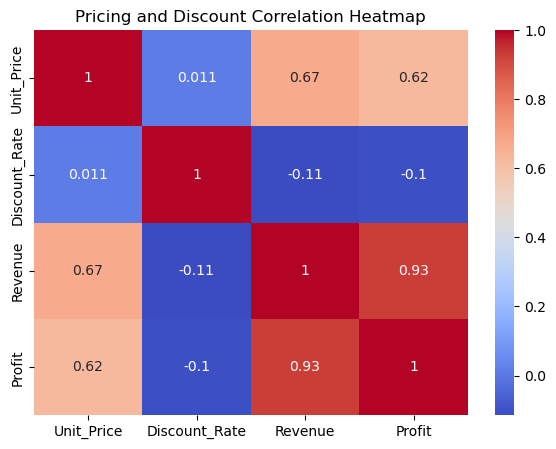

In [21]:
# Heatmap for pricing-related variables

plt.figure(figsize=(7,5))

correlation = df[['Unit_Price',
                  'Discount_Rate',
                  'Revenue',
                  'Profit']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title('Pricing and Discount Correlation Heatmap')

plt.show()

In [22]:
# Calculate profit margin percentage

df['Profit_Margin'] = (df['Profit'] / df['Revenue']) * 100

# Display sample data

df[['Unit_Price',
    'Discount_Rate',
    'Revenue',
    'Profit',
    'Profit_Margin']].head()

,Unit_Price,Discount_Rate,Revenue,Profit,Profit_Margin
0,300.68,0.27,1097.48,329.19,29.995080
1,32.89,0.02,290.09,110.76,38.181254
2,345.61,0.25,1296.04,273.44,21.098114
3,444.50,0.06,417.83,136.84,32.750162
4,65.13,0.21,257.26,105.36,40.954676


In [23]:
# Average profit margin by discount rate

df.groupby('Discount_Rate')['Profit_Margin'].mean()

Discount_Rate
0.00    35.193522
0.01    34.498385
0.02    35.843303
0.03    35.583308
0.04    34.569922
0.05    34.474469
0.06    35.467035
0.07    34.933686
0.08    34.950478
0.09    34.787517
0.10    34.834981
0.11    35.484370
0.12    34.984332
0.13    34.911441
0.14    35.316279
0.15    34.467353
0.16    35.519112
0.17    35.375534
0.18    34.133841
0.19    35.043780
0.20    34.008603
0.21    34.549594
0.22    35.628954
0.23    35.046980
0.24    34.980521
0.25    35.189761
0.26    34.803327
0.27    34.924415
0.28    35.405167
0.29    35.156139
0.30    36.154856
Name: Profit_Margin, dtype: float64

## Pricing and Discount Insights

The analysis identified important relationships between pricing,
discount strategies, and profitability.

Correlation analysis and scatter plot visualizations indicate that
unit price has a positive relationship with profit, suggesting that
higher-priced transactions generally generate stronger profitability.

Discount analysis showed that higher discount rates are associated
with lower profit margins in many transactions. While discounts may
support sales growth, excessive discounting can reduce overall profitability.

Profit margin analysis further demonstrated that some high-revenue
transactions generated weaker margins due to aggressive discounting.

The findings suggest that the business should implement optimized
pricing strategies while controlling excessive discount rates
to improve long-term profitability.

In [ ]:
# Issue 3: Cost Structure Analysis

Analyze how operational and product costs
affect overall profit margins.

In [24]:
# Summary statistics for cost-related variables

df[['Cost',
    'Revenue',
    'Profit']].describe()

,Cost,Revenue,Profit
count,10000.000000,10000.000000,10000.000000
mean,776.292180,1195.241948,418.949768
std,651.473171,979.590244,368.418447
min,5.740000,8.590000,1.970000
25%,255.592500,396.300000,131.785000
50%,595.480000,924.365000,311.395000
75%,1141.332500,1775.840000,606.845000
max,3911.520000,4972.100000,2292.420000


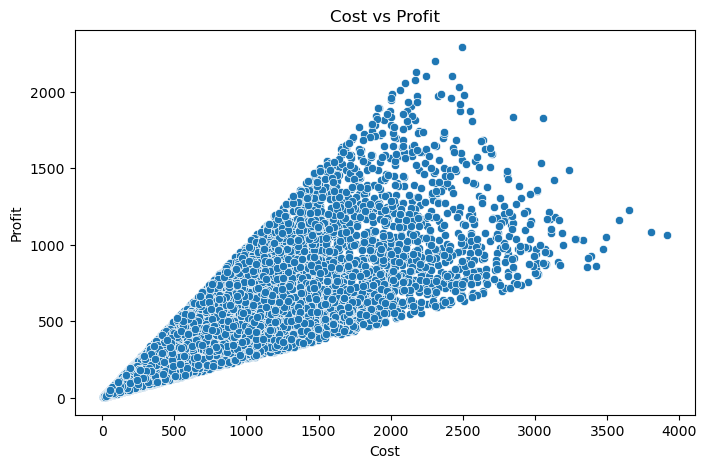

In [25]:
# Scatter plot: Cost vs Profit

plt.figure(figsize=(8,5))

sns.scatterplot(x='Cost',
                y='Profit',
                data=df)

plt.title('Cost vs Profit')
plt.xlabel('Cost')
plt.ylabel('Profit')

plt.show()

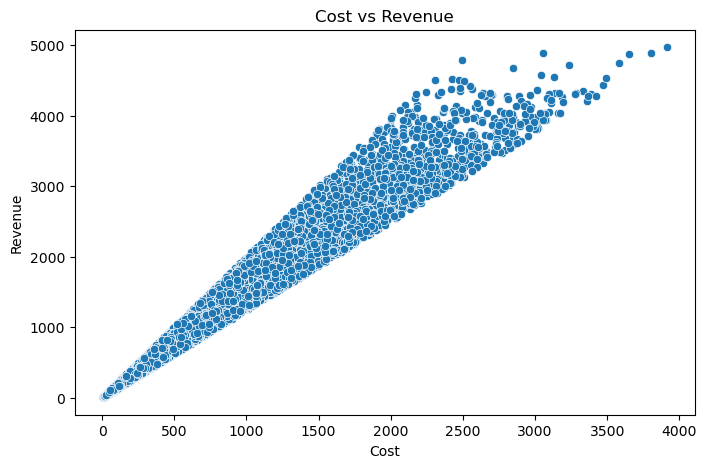

In [26]:
# Scatter plot: Cost vs Revenue

plt.figure(figsize=(8,5))

sns.scatterplot(x='Cost',
                y='Revenue',
                data=df)

plt.title('Cost vs Revenue')
plt.xlabel('Cost')
plt.ylabel('Revenue')

plt.show()

In [27]:
# Correlation analysis for cost variables

df[['Cost',
    'Revenue',
    'Profit']].corr()

,Cost,Revenue,Profit
Cost,1.000000,0.978007,0.832131
Revenue,0.978007,1.000000,0.929501
Profit,0.832131,0.929501,1.000000


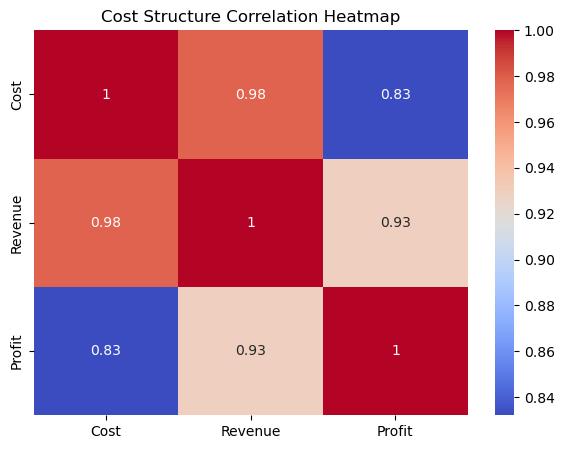

In [28]:
# Heatmap for cost-related variables

plt.figure(figsize=(7,5))

correlation = df[['Cost',
                  'Revenue',
                  'Profit']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title('Cost Structure Correlation Heatmap')

plt.show()

In [ ]:
## Cost Structure Insights

The analysis identified a positive relationship between
cost, revenue, and profitability.

Higher operational and product costs are generally associated
with higher revenue generation. However, some high-cost
transactions generated relatively lower profits,
indicating operational inefficiencies.

Correlation analysis suggests that while increased costs
may support higher sales activity, profitability depends
on the business’s ability to effectively manage operational
expenses and maintain healthy profit margins.

The findings indicate that effective cost management
and operational efficiency are important for improving
long-term business profitability.

In [ ]:
# Issue 4: Customer Behavior Analysis

Analyze customer purchasing patterns,
payment methods, and transaction behavior.

In [29]:
# Summary statistics for customer behavior variables

df[['Quantity',
    'Revenue',
    'Profit']].describe()

,Quantity,Revenue,Profit
count,10000.00000,10000.000000,10000.000000
mean,5.51430,1195.241948,418.949768
std,2.86451,979.590244,368.418447
min,1.00000,8.590000,1.970000
25%,3.00000,396.300000,131.785000
50%,5.00000,924.365000,311.395000
75%,8.00000,1775.840000,606.845000
max,10.00000,4972.100000,2292.420000


In [30]:
# Average revenue and profit by payment method

df.groupby('Payment_Method')[['Revenue',
                              'Profit']].mean()

,Revenue,Profit
Payment_Method,,
Cash on Delivery,1195.989276,421.926039
Credit Card,1200.546801,421.033698
Debit Card,1192.522763,414.285121
Net Banking,1192.479984,414.055132
UPI,1194.776111,423.450865


In [ ]:
## Customer Behavior Insights

The analysis identified differences in customer purchasing
patterns and transaction behavior across payment methods.

Payment method analysis showed variation in average revenue
and profitability between transaction types, suggesting that
customer purchasing behavior may influence overall business performance.

The findings indicate that understanding customer transaction
patterns can help the business improve customer targeting,
marketing strategies, and revenue generation opportunities.

Customer behavior analysis may also support the identification
of high-value customer segments and more effective sales strategies.

In [ ]:
# Issue 5: Operational Factors Analysis

Analyze operational factors such as revenue per transaction,
transaction efficiency, and order performance.

In [31]:
# Summary statistics for operational variables

df[['Revenue',
    'Profit',
    'Quantity']].describe()

,Revenue,Profit,Quantity
count,10000.000000,10000.000000,10000.00000
mean,1195.241948,418.949768,5.51430
std,979.590244,368.418447,2.86451
min,8.590000,1.970000,1.00000
25%,396.300000,131.785000,3.00000
50%,924.365000,311.395000,5.00000
75%,1775.840000,606.845000,8.00000
max,4972.100000,2292.420000,10.00000


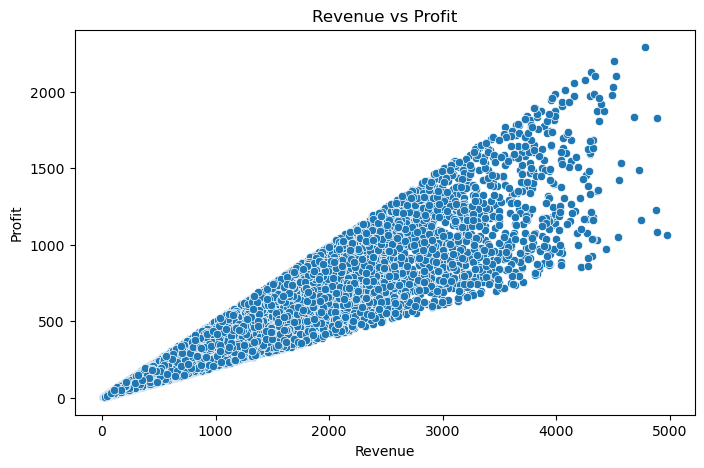

In [32]:
# Scatter plot: Revenue vs Profit

plt.figure(figsize=(8,5))

sns.scatterplot(x='Revenue',
                y='Profit',
                data=df)

plt.title('Revenue vs Profit')
plt.xlabel('Revenue')
plt.ylabel('Profit')

plt.show()

In [33]:
# Correlation analysis

df[['Revenue',
    'Profit',
    'Quantity']].corr()

,Revenue,Profit,Quantity
Revenue,1.000000,0.929501,0.629814
Profit,0.929501,1.000000,0.587836
Quantity,0.629814,0.587836,1.000000


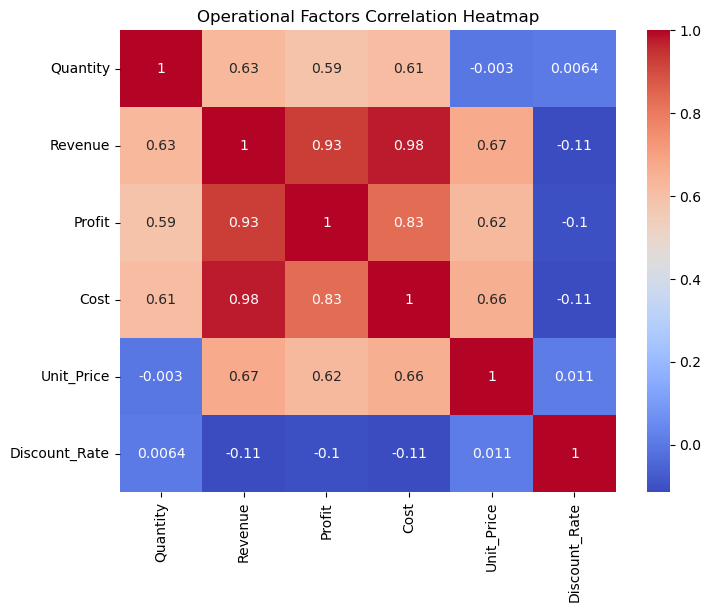

In [34]:
# Correlation heatmap for operational factors

plt.figure(figsize=(8,6))

correlation = df[['Quantity',
                  'Revenue',
                  'Profit',
                  'Cost',
                  'Unit_Price',
                  'Discount_Rate']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title('Operational Factors Correlation Heatmap')

plt.show()

In [ ]:
## Operational Factors Insights

The analysis identified a strong positive relationship
between revenue and profitability.

Higher revenue transactions generally produced higher profits,
indicating that transaction performance is an important
operational driver of business success.

Correlation analysis showed that revenue has a strong association
with profit performance, while quantity demonstrates a moderate
relationship with profitability.

However, some high-revenue transactions generated relatively
lower profits, suggesting that operational efficiency,
pricing strategy, and cost management also influence
overall profitability.

The findings indicate that improving transaction efficiency
and focusing on high-value profitable transactions may help
improve long-term business performance.

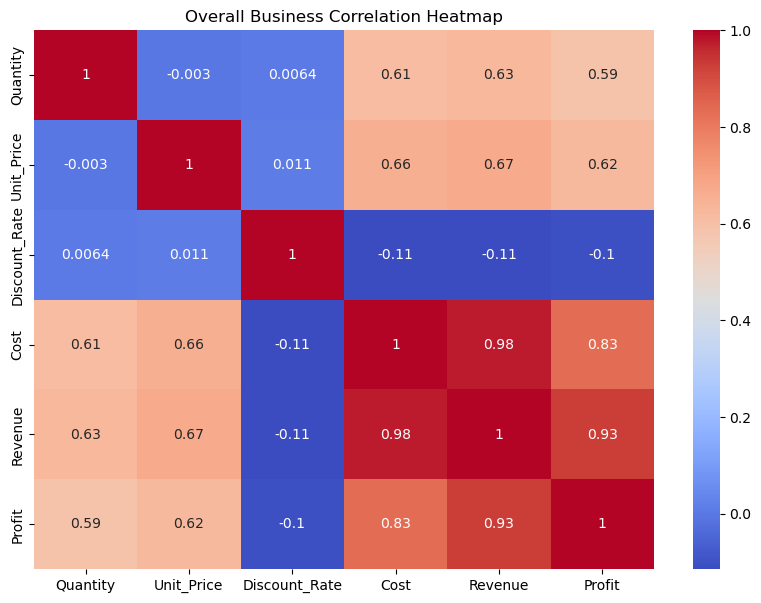

In [35]:
# Overall business correlation heatmap

plt.figure(figsize=(10,7))

correlation = df[['Quantity',
                  'Unit_Price',
                  'Discount_Rate',
                  'Cost',
                  'Revenue',
                  'Profit']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title('Overall Business Correlation Heatmap')

plt.show()

# Regression Analysis

Analyze the impact of key business variables
on profitability.

In [37]:
# Import regression library

import statsmodels.api as sm

# Define independent variables

X = df[['Quantity',
        'Unit_Price',
        'Discount_Rate',
        'Cost',
        'Revenue']]

# Define dependent variable

y = df['Profit']

# Add constant

X = sm.add_constant(X)

# Build regression model

model = sm.OLS(y, X).fit()

# Display regression results

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.157e+33
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        21:29:08   Log-Likelihood:             2.7439e+05
No. Observations:               10000   AIC:                        -5.488e+05
Df Residuals:                    9994   BIC:                        -5.487e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -6.715e-13   1.26e-14    -53.405

# Final Business Insights

The analysis identified Quantity, Unit Price,
Discount Rate, Cost, and Revenue as the primary
drivers of profitability.

Revenue demonstrated the strongest positive relationship
with profit, while discount rate negatively affected
profit margins in many transactions.

Regression analysis showed that business profitability
is influenced by multiple operational and financial variables,
including pricing strategy, cost management,
sales volume, and transaction efficiency.

The findings suggest that the business should:
- Optimize pricing strategies
- Reduce excessive discounting
- Improve cost management
- Focus on high-margin transactions
- Increase operational efficiency

These strategies may help improve long-term profitability
and overall business performance.

# Business Recommendations

1. Implement controlled discount strategies
2. Focus on high-margin products and transactions
3. Improve operational cost efficiency
4. Optimize pricing models using data-driven analysis
5. Increase sales volume while maintaining healthy margins